# LSTM-Based Sentiment Analysis

**Name:** Pradeep Manikandan D  
**Roll Number:** 24BAD088  

**Dataset:** Built-in IMDB Movie Reviews dataset  
**Framework:** TensorFlow / Keras

## AIM
To implement a Long Short-Term Memory (LSTM) network for sentiment analysis by performing text preprocessing, tokenization, sequence generation, embedding, and sentiment classification.

## OBJECTIVES
- Understand the architecture and working of LSTM networks.
- Perform text preprocessing for sentiment analysis.
- Tokenize and convert textual data into numerical sequences.
- Generate word embeddings.
- Build and train an LSTM model for sentiment classification.
- Evaluate the trained model using suitable metrics.

In [1]:
# PART A: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## PART A: DATASET PREPARATION AND TEXT PREPROCESSING

In [2]:
# Load the built-in IMDB dataset
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print('Training samples:', len(x_train))
print('Testing samples:', len(x_test))
print('Positive samples:', np.sum(y_train == 1))
print('Negative samples:', np.sum(y_train == 0))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 62s 4us/step
Training samples: 25000
Testing samples: 25000
Positive samples: 12500
Negative samples: 12500


In [3]:
# Examine sample reviews as encoded sequences
print('First review sequence:')
print(x_train[0][:30])
print('First review label:', y_train[0])
print('Review length:', len(x_train[0]))


First review sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]
First review label: 1
Review length: 218


In [4]:
# Apply sequence padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post')

print('Training shape after padding:', x_train.shape)
print('Testing shape after padding:', x_test.shape)


Training shape after padding: (25000, 200)
Testing shape after padding: (25000, 200)


### PART B: EMBEDDING GENERATION
The Embedding layer converts integer word indices into dense numerical vectors. The LSTM then learns useful sequential patterns from these representations.

In [5]:
# Define embedding parameters
embedding_dim = 64

embedding_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len)
])

embedding_output = embedding_model.predict(x_train[:1], verbose=0)
print('Embedding representation shape:', embedding_output.shape)


c:\Users\PRADEEP MANIKANDAN D\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Embedding representation shape: (1, 200, 64)


## PART C: IMPLEMENTING THE LSTM MODEL

In [6]:
# Build the LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## PART D: MODEL TRAINING AND SENTIMENT PREDICTION

In [7]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 132ms/step - accuracy: 0.5500 - loss: 0.6777 - val_accuracy: 0.5704 - val_loss: 0.6555
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.6502 - loss: 0.5890 - val_accuracy: 0.8056 - val_loss: 0.5209
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.6967 - loss: 0.5463 - val_accuracy: 0.6352 - val_loss: 0.5931
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.7943 - loss: 0.4458 - val_accuracy: 0.8180 - val_loss: 0.4532
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.8246 - loss: 0.4038 - val_accuracy: 0.7246 - val_loss: 0.5618


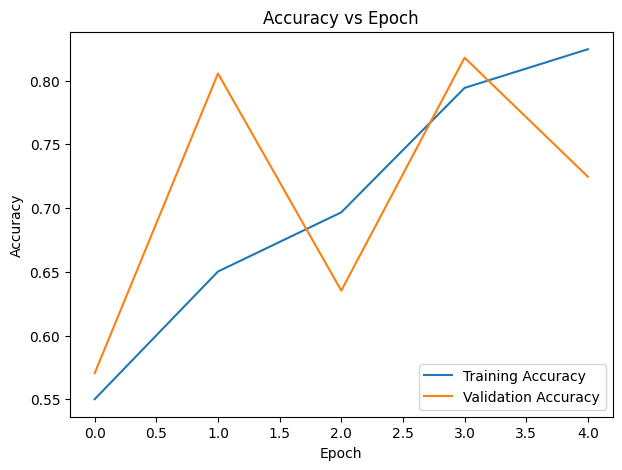

In [8]:
# Plot accuracy vs epoch
plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()


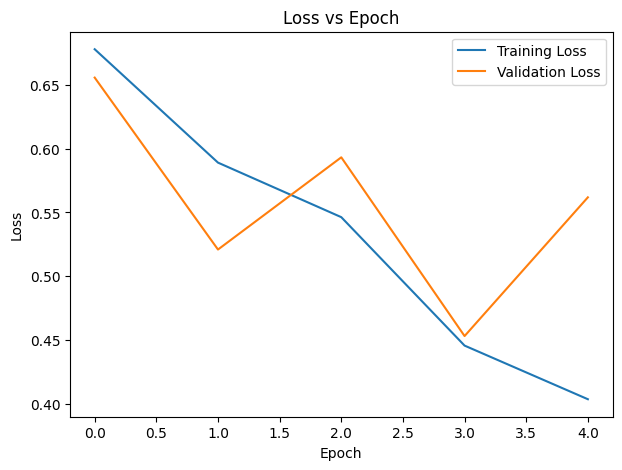

In [9]:
# Plot loss vs epoch
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()


In [10]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)


Test Loss: 0.5484625101089478
Test Accuracy: 0.7312399744987488


In [11]:
# Calculate precision, recall, F1-score and confusion matrix
y_prob = model.predict(x_test, verbose=0)
y_pred = (y_prob >= 0.5).astype(int).flatten()

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1-score:', f1_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))


Accuracy: 0.73124
Precision: 0.8108398752554038
Recall: 0.6032
F1-score: 0.6917748520574338

Classification Report:

              precision    recall  f1-score   support

    Negative       0.68      0.86      0.76     12500
    Positive       0.81      0.60      0.69     12500

    accuracy                           0.73     25000
   macro avg       0.75      0.73      0.73     25000
weighted avg       0.75      0.73      0.73     25000

Confusion Matrix:
 [[10741  1759]
 [ 4960  7540]]


In [12]:
# Predict sentiment for sample reviews
word_index = imdb.get_word_index()
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index['<PAD>'] = 0
word_index['<START>'] = 1
word_index['<UNK>'] = 2
word_index['<UNUSED>'] = 3

def encode_review(text):
    words = text.lower().split()
    sequence = [1]
    for word in words:
        sequence.append(word_index.get(word, 2))
    return pad_sequences([sequence], maxlen=max_len, padding='post')

sample_reviews = [
    'This movie was excellent and I really enjoyed it',
    'The movie was boring and disappointing'
]

for review in sample_reviews:
    prediction = model.predict(encode_review(review), verbose=0)[0][0]
    sentiment = 'Positive' if prediction >= 0.5 else 'Negative'
    print('Review:', review)
    print('Predicted sentiment:', sentiment)
    print('Probability:', round(float(prediction), 4))
        

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Review: This movie was excellent and I really enjoyed it
Predicted sentiment: Positive
Probability: 0.8505
Review: The movie was boring and disappointing
Predicted sentiment: Negative
Probability: 0.4132


## EXPECTED OUTCOME
The LSTM model learns sequential information from movie reviews and classifies them as positive or negative. The experiment demonstrates text preprocessing, tokenization, sequence padding, embedding generation, LSTM training, sentiment prediction, and evaluation using accuracy, precision, recall, F1-score, and confusion matrix.